# Notebook Description

This notebook examines customer feedback text from the feedbacks.csv dataset. We would like to apply the same baseline to advanced model evaluation approach we did for driver ratings. For the case of text data, we would supposedly use term frequency-inverse document frequency (TF-IDF) paired with logistic regression as our baseline, and using a pretrained transformer as our advanced model for evaluation.  


However, since the feedbacks dataset does not contain a sentiment label (something that would serve as ground truth), TF-IDF and logistic regression is not possible, since they are supervised learning methods. Hence we a different approach for baseline evaluation, and that is using VADER (Valence Aware Dictionary and sentiment Reasoner). It is nothing but a rule-based analyzer with a pre-built dictionary of words with corresponding ratings for how positive or negative a word is. Then, the advanced model that will build up on the baseline will  be a zero-shot pretrained transformer model from Hugging Face. 

# Import

### Modules

In [1]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

### The Data

In [2]:
feedbacks = pd.read_csv('../data/feedbacks.csv')

In [3]:
feedbacks.head()

,trip_id,driver_id,feedback_txt,timestamp
0,TRP-100-001,DRV100395,The package arrived within the expected window...,2026-05-19 13:05:21
1,TRP-100-002,DRV100381,"The package was clean and presentable, and the...",2026-04-21 16:40:06
2,TRP-100-003,DRV100508,"The delivery arrived on time, but the contents...",2026-03-07 09:03:45
3,TRP-100-004,DRV100293,"The parcel still looked properly sealed, and t...",2026-05-17 11:24:03
4,TRP-100-005,DRV100076,The order was delayed more than I was comforta...,2026-04-04 15:07:38


# BASELINE

VADER evaluates polarity score for each feedback txt. It then returns a dictionary with four value types (neg, neu, pos, compound), where compound is the aggregated score that vader recommends for overall sentiment classification. thus, it is the one we select. 

In [4]:
analyzer = SentimentIntensityAnalyzer()

feedbacks['vader_compound'] = feedbacks['feedback_txt'].apply(
    lambda txt: analyzer.polarity_scores(txt)['compound']
)

We then convert the compound scores into three classes. VADER's documentation explicitly provides standard conventions for thresholds for score to class conversions. 

In [5]:
def compound_to_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

feedbacks['vader_label'] = feedbacks['vader_compound'].apply(compound_to_label)

Then, we take a look at the classes. 

In [6]:
feedbacks.head()

,trip_id,driver_id,feedback_txt,timestamp,vader_compound,vader_label
0,TRP-100-001,DRV100395,The package arrived within the expected window...,2026-05-19 13:05:21,0.8271,positive
1,TRP-100-002,DRV100381,"The package was clean and presentable, and the...",2026-04-21 16:40:06,0.7151,positive
2,TRP-100-003,DRV100508,"The delivery arrived on time, but the contents...",2026-03-07 09:03:45,0.3291,positive
3,TRP-100-004,DRV100293,"The parcel still looked properly sealed, and t...",2026-05-17 11:24:03,0.3400,positive
4,TRP-100-005,DRV100076,The order was delayed more than I was comforta...,2026-04-04 15:07:38,0.7650,positive


In [7]:
feedbacks['vader_label'].value_counts(normalize=True)

vader_label
positive    0.873999
neutral     0.086492
negative    0.039509
Name: proportion, dtype: float64

Positive labels take up most of the feedback texts' composition at around 79% with only 6% of the text having negative sentiment.

In [8]:
for label in ['positive', 'neutral', 'negative']:
    print(f"\n--- {label.upper()} examples ---")
    sample = feedbacks[feedbacks['vader_label'] == label]['feedback_txt'].sample(3, random_state=42)
    for txt in sample:
        print(f"  {txt}")


--- POSITIVE examples ---
  The package arrived within the expected window. The package was intact, and the handoff was okay. It was a fair delivery experience.
  The package was intact, although the delivery took longer than i hoped. The package was handed over quickly.
  The delivery timing was reliable. The parcel arrived in good condition, and the driver greeted me properly and handed over the parcel well.

--- NEUTRAL examples ---
  The parcel was delivered at the expected time, and the package looked properly handled. The courier handled the delivery properly at the door.
  The parcel took too long to arrive. The package looked properly handled, and the courier completed the delivery without much issue. I received the package, but the service could be more consistent.
  The delivery was completed promptly, but the box had noticeable creases. The package was handed over quickly.

--- NEGATIVE examples ---
  The delivery missed the expected time window, but the box had noticeable 

Spot-checking VADER's labels against the actual text shows the classifications hold up well. Negative examples consistently cite a concrete complaint, most often a missed delivery window, which is a clear and legitimate basis for a negative label. Positive examples cite explicit satisfaction cues, such as "reliable," "good condition," "greeted me properly", which is language that straightforwardly supports a positive read. Neutral examples are the most interesting case thoughg, as each one mixes a positive and a negative detail in the same comment (e.g., "took too long to arrive" alongside "package looked properly handled"), which is exactly the kind of mixed signal a neutral label is meant to capture, rather than forcing the comment into one extreme or the other.

Overall, VADER's lexicon-matching performs reliably here, since the feedback language is explicit and largely unambiguous. This gives us a solid, interpretable baseline to compare the pretrained transformer against.

# Pre-trained Transformers

We will use `cardiffnlp/twitter-roberta-base-sentiment-latest`, a popular RoBERTa-base transformer on Hugging Face. Though it is mostly used for market research and social media monitoring, it is also suitable for our case, since it excels in 3-class sentiment analysis. 

In [9]:
import torch
from transformers import pipeline 

device = 0 if torch.cuda.is_available() else -1

sentiment_pipe = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    device=device
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
# confirming if we have access to the CUDA-enabled GPU 
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5070


Batch size was set to 256 to take advantage of GPU compute power (if available), which allows the transformer to process rows in parallel.

In [11]:
results = sentiment_pipe(
    feedbacks['feedback_txt'].to_list(),
    batch_size=256, 
    truncation=True
)

Then, extract the transformer's label and score for each observation. 

In [12]:
feedbacks['transformer_label'] = [r['label'].lower() for r in results]
feedbacks['transformer_score'] = [r['score'] for r in results]

### Comparing VADER and the Transformer

In [13]:
feedbacks['vader_label'].value_counts(normalize=True)

vader_label
positive    0.873999
neutral     0.086492
negative    0.039509
Name: proportion, dtype: float64

In [14]:
feedbacks['transformer_label'].value_counts(normalize=True)

transformer_label
positive    0.884378
neutral     0.088497
negative    0.027125
Name: proportion, dtype: float64

In [15]:
print(pd.crosstab(feedbacks['vader_label'], feedbacks['transformer_label'], rownames=['VADER'], colnames=['Transformer']))


Transformer  negative  neutral  positive
VADER                                   
negative          415      872      1393
neutral           456     1275      4136
positive          969     3856     54461


In [16]:
agreement = (feedbacks['vader_label'] == feedbacks['transformer_label']).mean()
print(f"\nVADER vs Transformer agreement: {agreement:.2%}")


VADER vs Transformer agreement: 82.78%


The pretrained RoBERTa model shows almost minimal difference from VADER's label proportions overall. Most positive predictions remained roughly the same, with neutral and negative proportions shifting slightly. The transformer appears to label somewhat more text as neutral rather than negative. The diagonal of the cross-tabulation above shows the number of rows where VADER and the transformer agreed on a label.

To look more closely at the disagreements, we pull a couple of specific examples where the two methods diverged and check which call actually holds up.

In [17]:
noisy_examples = [
    "The order reached me withotu delay. The contents did not fele as secrue as expected, and the cuorier was respectflu during delivery.",
    "The box had no visible mark, and the courier handed ovr the package caefully.",
]

print(sentiment_pipe(noisy_examples[0]))
print(sentiment_pipe(noisy_examples[1]))

[{'label': 'negative', 'score': 0.7791938781738281}]
[{'label': 'neutral', 'score': 0.8243451714515686}]


The transformer labeled the first example negative (0.78 confidence) and the second neutral (0.82 confidence), both disagreeing with VADER's original positive call on these two rows. On inspection, the second call looks correct, as the text is purely descriptive ("no visible mark," "handled carefully") with no actual evaluative language, so neutral is the more defensible label here, not VADER's positive. The first example is more genuinely mixed ("did not feel as secure as expected" alongside "respectful"), making negative a defensible call rather than a clear error, though VADER's positive read isn't unreasonable either given the explicit "respectful" mention.

This suggests the transformer isn't simply "better" or "worse" than VADER, but rather it reasons about sentiment differently, and some disagreements reflect genuine ambiguity in the text rather than a clear failure of either method. A full comparison would benefit from human spot-checks across a larger sample of disagreements, rather than assuming either model's label is automatically correct.

## Topic Modeling for Complaint Clustering

Now that we've labeled sentiment, we want to further our analysis and identify what customers are actually talking about. That is by grouping feedback into underlying themes (e.g., late delivery, package condition, courier attitude) without manually defining categories ourselves.

The two standard unsupervised options are Latent Dirichlet Allocation (LDA), which groups documents based on word co-occurrence patterns, and BERTopic, which clusters documents based on semantic meaning via transformer embeddings. Yet again, we choose the transformer model again (BERTopic) here because our feedback text is short (often a single sentence) and phrased inconsistently across rows. These are some conditions where LDA's word-overlap assumption tends to break down, while BERTopic can still group semantically similar complaints even when they share few or no words in common.

In [18]:
from bertopic import BERTopic

We'll start by deduplicating the feedback text before running it through BERTopic. We run this as a good measure as there is no value in making BERTopic embed and cluster exact same strings. After that, we fit the model on unique texts and then map the resulting topics back to every row afterward.

In [19]:
unique_texts = feedbacks['feedback_txt'].drop_duplicates().reset_index(drop=True)

In [20]:
topic_model = BERTopic(language='english', min_topic_size=30, verbose=True)
topics, probs = topic_model.fit_transform(unique_texts.tolist())

2026-06-30 12:19:39,861 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1241 [00:00<?, ?it/s]

2026-06-30 12:19:57,451 - BERTopic - Embedding - Completed ✓
2026-06-30 12:19:57,452 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 12:20:19,896 - BERTopic - Dimensionality - Completed ✓
2026-06-30 12:20:19,898 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 12:20:22,746 - BERTopic - Cluster - Completed ✓
2026-06-30 12:20:22,752 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 12:20:23,207 - BERTopic - Representation - Completed ✓


In [21]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8185,-1_handoff_parcel_to_received,"[handoff, parcel, to, received, order, driver,...","[The package arrived much later than expected,..."
1,0,688,0_fine_when_it_box,"[fine, when, it, box, looked, courier, arrived...","[The box looked fine when it arrived, and the ..."
2,1,619,1_by_delayed_too_not,"[by, delayed, too, not, much, but, package, co...","[The package was delayed, but not by too much,..."
3,2,592,2_care_normally_quickly_handed,"[care, normally, quickly, handed, over, cared,...","[The package arrived looking well cared for, a..."
4,3,562,3_intact_courier_issue_respectful,"[intact, courier, issue, respectful, much, han...","[The package was intact, although the package ..."
...,...,...,...,...,...
294,293,31,293_any_issues_damage_received,"[any, issues, damage, received, without, item,...","[The item was received without visible damage,..."
295,294,30,294_again_happy_would_within,"[again, happy, would, within, window, to, be, ...","[The package looked properly handled, and the ..."
296,295,30,295_comfortable_delayed_more_with,"[comfortable, delayed, more, with, professiona...",[The order was delayed more than I was comfort...
297,296,30,296_clean_presentable_handing_courteous,"[clean, presentable, handing, courteous, when,...","[The package was clean and presentable, and th..."


Our initial fit produced close to over 300 topics, mostly fragmented sub-variants of the same few themes. We reduce this down to a more interpretable number of topics to get a cleaner view of the actual underlying complaint categories.

In [22]:
topic_model.reduce_topics(unique_texts.to_list(), nr_topics=15)

2026-06-30 12:20:32,860 - BERTopic - Topic reduction - Reducing number of topics
2026-06-30 12:20:32,883 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 12:20:33,233 - BERTopic - Representation - Completed ✓
2026-06-30 12:20:33,237 - BERTopic - Topic reduction - Reduced number of topics from 299 to 15


In [23]:
print(topic_model.get_topic_info())

    Topic  Count                            Name  \
0      -1   8185         -1_the_was_and_delivery   
1       0  12641           0_the_was_package_and   
2       1   6490        1_timing_the_without_was   
3       2   3460     2_within_the_window_package   
4       3   2809          3_handoff_was_okay_the   
5       4   1706          4_marks_no_had_visible   
6       5   1604  5_damage_received_item_visible   
7       6    684         6_creases_few_light_had   
8       7    578  7_uneven_contents_although_the   
9       8    577         8_outside_minor_wear_on   
10      9    331  9_dented_corners_edges_visibly   
11     10    293  10_slight_creasing_seemed_fine   
12     11    148     11_areas_compressed_some_in   
13     12    111   12_shaken_rough_showed_seemed   
14     13     78       13_firmly_place_stay_seem   

                                       Representation  \
0   [the, was, and, delivery, parcel, package, arr...   
1   [the, was, package, and, delivery, arrived, pa...

In [24]:
reduced_topics = topic_model.topics_   

topic_lookup = pd.Series(reduced_topics, index=unique_texts).to_dict()
feedbacks['topic'] = feedbacks['feedback_txt'].map(topic_lookup)

Topic 0 dominates the dataset at nearly 19,000 documents. Sampling its contents shows it's a coherent "general satisfaction" theme. Reviews with no specific complaint, often touching lightly on timing, condition, and courier attitude without dwelling on any one of them ("smooth delivery experience," "would be happy to order again," "met my expectations"). The remaining topics (1–13) are almost entirely package-condition complaints, split into fine-grained sub-types (creasing, denting, compression, shifting). This makes sense: positive feedback tends to be short and generic, while complaints are naturally more descriptive and specific, giving them more distinct vocabulary to cluster on.

In [25]:
topic_0_docs = [doc for doc, t in zip(unique_texts, reduced_topics) if t == 0]
print(len(topic_0_docs))

import random
random.seed(42)
for doc in random.sample(topic_0_docs, 15):
    print(doc, "\n")

12641
The delivery took longer than I hoped. The box had marks that made it look roughly handled, and the driver was polite during the handoff. Overall, the delivery was acceptable. 

The parcel looked neat upon arrival, and the courier was courteous when handing over the package. The delivery arrived on time. 

The package was clean and presentable, and the courier handled the delivery properly at the door. 

The package was clean and presentable, and the interaction felt less courteous than expected. The package was delayed, but not by too much. 

The delivery was late. The package looked properly handled, and the driver greeted me properly and handed over the parcel well. It was a fair delivery experience. 

The package arrived looking well cared for, and the courier completed the delivery without much issue. The delivery arrived on time. 

The order arrived later than planned. The package looked properly handled, and the package was handed over normally. 

The package was clean and

Topic -1 (the outlier bucket) turns out to be coherent as well, rather than unclusterable noise. Sampling its contents shows a consistent pattern: mixed-sentiment reviews that pair a positive detail with a negative or qualifying one in the same comment (e.g., "missed the expected time window" alongside "courier was respectful"). These sit between the positive and complaint clusters in embedding space, which is why HDBSCAN (the clustering algo used by BERTopic) doesn't assign them to either. 

In [26]:
topic_neg1_docs = [doc for doc, t in zip(unique_texts, reduced_topics) if t == -1]
print(len(topic_neg1_docs))

import random
random.seed(42)
for doc in random.sample(topic_neg1_docs, 15):
    print(doc, "\n")

8185
The parcel looked neat upon arrival, and the package was handed over normally. The order was delayed more than I was comfortable with. Everything went well overall. 

The parcel was delivered at the expected time, and the package looked properly handled. The courier handed over the package carefully. 

The delivery was completed promptly. The package was intact, and the delivery process at the doorstep was organized. I would be happy to order again. 

The order was delayed more than I was comfortable with. The parcel arrived in good condition, and the interaction during delivery was acceptable. The service met my expectations. 

The order reached me without delay, and the parcel still looked properly sealed. The package was handed over with care. Everything went well overall. 

The order reached me without delay. The parcel still looked properly sealed, and the driver greeted me properly and handed over the parcel well. Overall, I was satisfied with the delivery. 

The package arr

To visualize the discovered topics, we build one word cloud per topic using BERTopic's own extracted top words and their relevance scores (`get_topic()`). Word size reflects how strongly that word characterizes the topic, so each cloud gives a quick visual summary of what that group of complaints/reviews is actually about — without needing to read through the raw representative documents one by one.

In [27]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

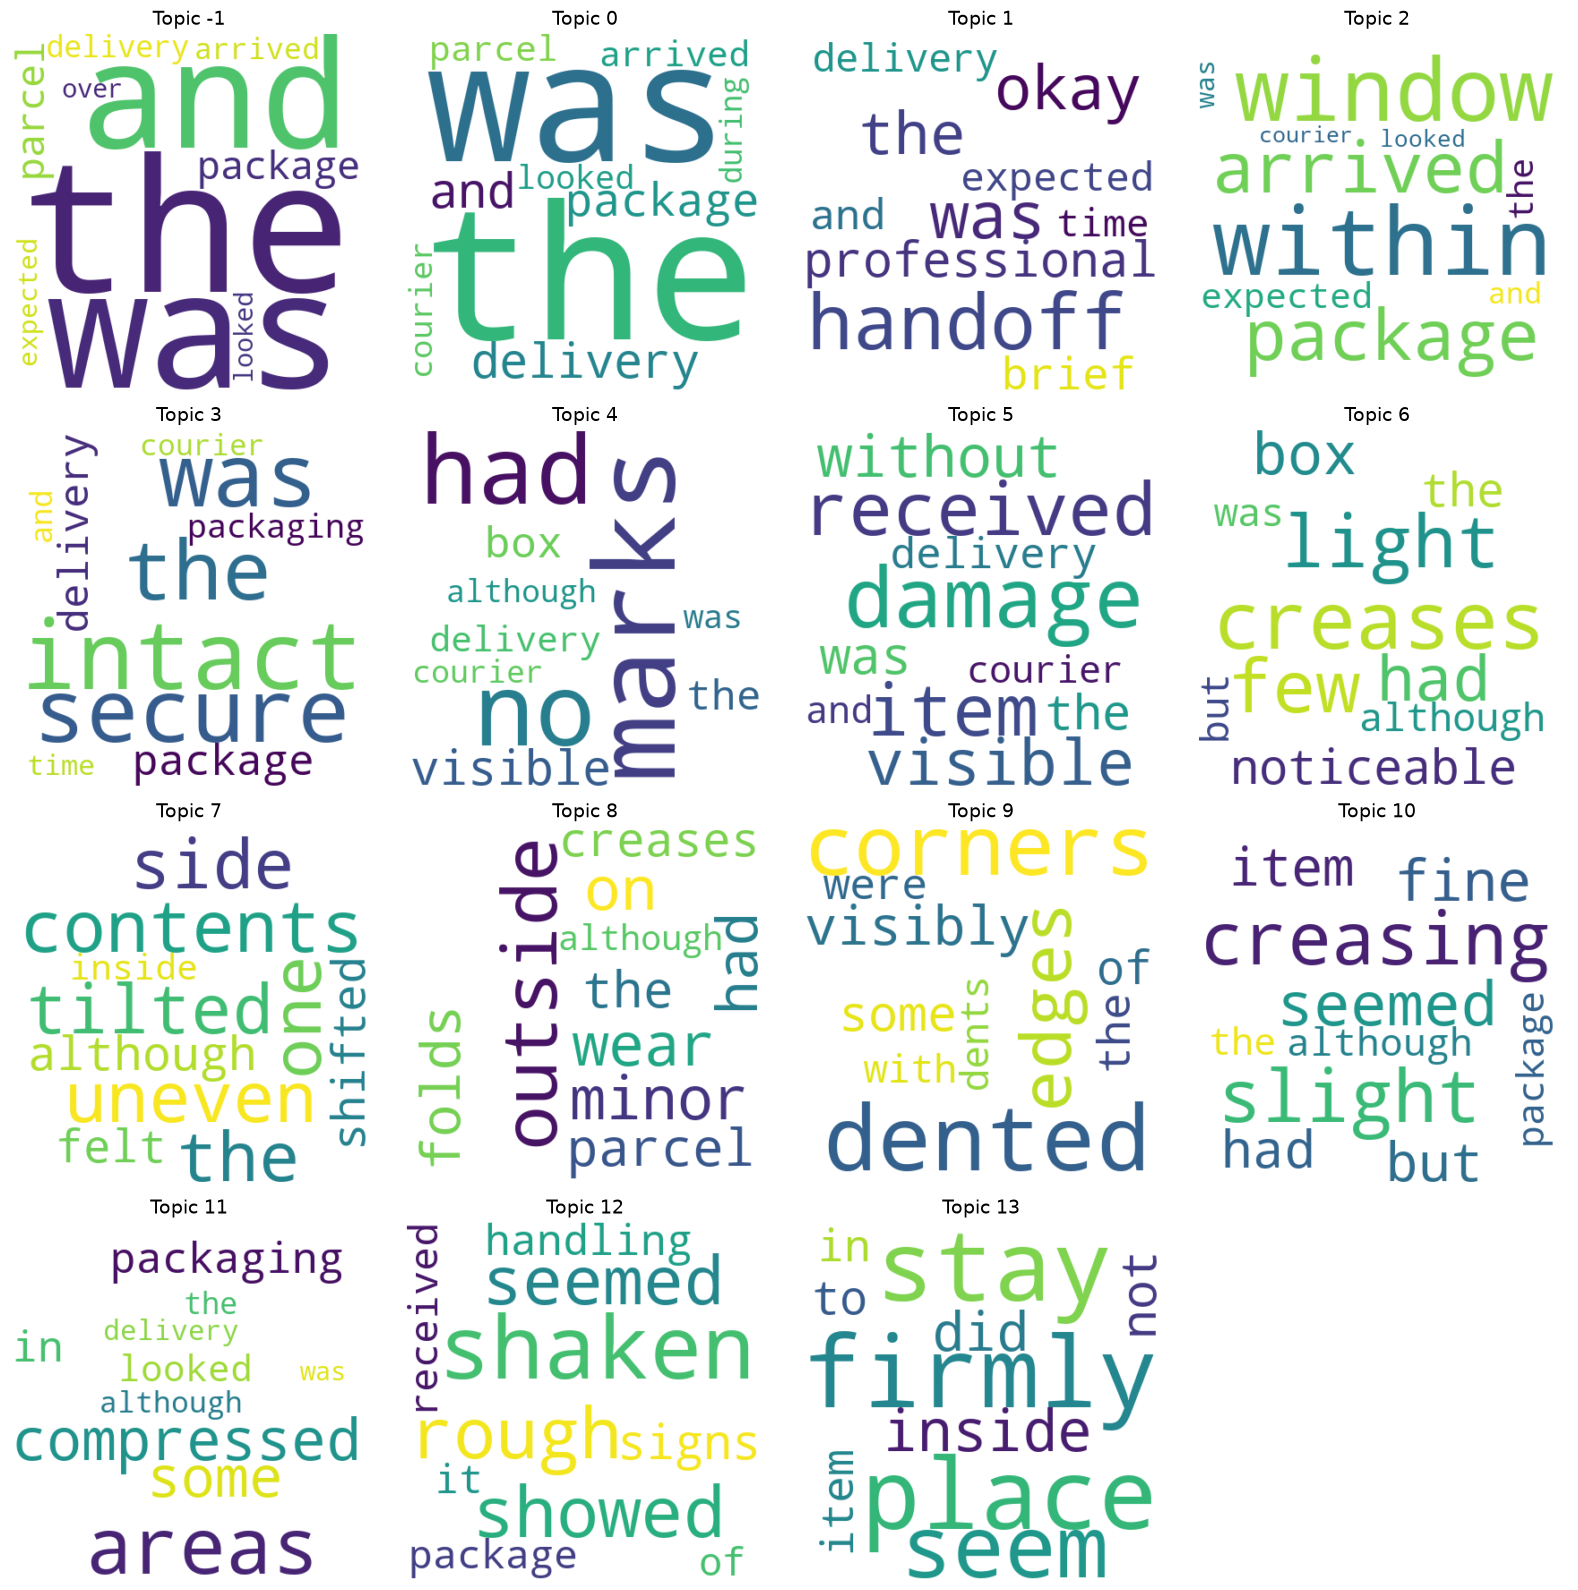

In [59]:
topic_ids = sorted(topic_model.get_topic_info()['Topic'].tolist())  # includes -1 through 13

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, topic_id in enumerate(topic_ids):
    word_scores = dict(topic_model.get_topic(topic_id))  # {word: score} for this topic
    wc = WordCloud(background_color='white', width=400, height=400).generate_from_frequencies(word_scores)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Topic {topic_id}", fontsize=14)
    axes[i].axis('off')

for j in range(len(topic_ids), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

The word clouds make the topic structure visible at a glance. Topics -1 and 0, our *mixed experience* and *general satisfaction* themes, are dominated by generic, low-information words like "the," "was," and "and," which makes sense given these clusters group documents by overall tone rather than a specific issue, so no single descriptive word stands out. In sharp contrast, Topics 1 through 13 each surface clearly distinct, concrete vocabulary tied to a specific complaint type: "professional"/"handoff" for courier interactions, "within"/"window" for timing, and a long tail of package-condition language that splits into surprisingly fine-grained sub-themes: "creases," "dented corners," "tilted," "shaken," "compressed." 

This confirms our earlier finding that complaints carry far richer, more specific vocabulary than satisfied feedback, which is why they fragment into more topics despite making up a smaller share of the data. Together with the sentiment analysis, this gives a fairly complete picture that most feedback is positive and non-specific, a meaningful minority is mixed, and the concrete, actionable complaints are overwhelmingly about package condition due to driver handling rather than timing or driver behavior alone.

#### Saving the Model